                       MEAN PERFORMANCE METRICS GROUPED BY BALANCING PIPELINE                       

Mean Performance Metrics by Pipeline (across all models and datasets):

               Count     AUC      F1  Accuracy  Precision  Recall_1  Recall_0
Pipeline                                                                    
CTGAN            14  0.7725  0.6473    0.6934     0.6028    0.7428    0.6611
No Balancing     14  0.7919  0.6587    0.6856     0.5857    0.7845    0.6237
ROS              14  0.7945  0.6773    0.7207     0.6307    0.7528    0.7021
SMOTE            14  0.7900  0.6480    0.6941     0.6009    0.7480    0.6607
--------------------------------------------------------------------------------

Styled Table:


,Count,AUC,F1,Accuracy,Precision,Recall_1,Recall_0
Pipeline,,,,,,,
CTGAN,14,0.7725,0.6473,0.6934,0.6028,0.7428,0.6611
No Balancing,14,0.7919,0.6587,0.6856,0.5857,0.7845,0.6237
ROS,14,0.7945,0.6773,0.7207,0.6307,0.7528,0.7021
SMOTE,14,0.7900,0.6480,0.6941,0.6009,0.7480,0.6607




                            MEAN PERFORMANCE METRICS FOR TCGA TEST ONLY                             

Mean Performance Metrics by Pipeline (TCGA Test only):

               Count     AUC      F1  Accuracy  Precision  Recall_1  Recall_0
Pipeline                                                                    
CTGAN             7  0.8446  0.7386    0.7593     0.6800    0.8204    0.7157
No Balancing      7  0.8648  0.7489    0.7568     0.6857    0.8449    0.6939
ROS               7  0.8669  0.7681    0.7976     0.7330    0.8082    0.7901
SMOTE             7  0.8620  0.7234    0.7594     0.6953    0.8041    0.7274
--------------------------------------------------------------------------------


                               MEAN PERFORMANCE METRICS FOR CGGA ONLY                               

Mean Performance Metrics by Pipeline (CGGA only):

               Count     AUC      F1  Accuracy  Precision  Recall_1  Recall_0
Pipeline                                                       

,Pipeline,TCGA AUC,CGGA AUC,AUC Drop,TCGA F1,CGGA F1,F1 Drop,TCGA Acc,CGGA Acc,Acc Drop
3,ROS,0.8669,0.7222,0.1447,0.7681,0.5865,0.1816,0.7976,0.6438,0.1538
0,No Balancing,0.8648,0.7190,0.1458,0.7489,0.5686,0.1803,0.7568,0.6144,0.1424
1,SMOTE,0.8620,0.7180,0.1439,0.7234,0.5727,0.1507,0.7594,0.6289,0.1305
2,CTGAN,0.8446,0.7004,0.1442,0.7386,0.5560,0.1826,0.7593,0.6274,0.1320




                              BAR CHART: AVERAGE TCGA AUC PER PIPELINE                              

Average TCGA AUC by Pipeline:
                mean     std
Pipeline                    
ROS           0.8669  0.0439
No Balancing  0.8648  0.0428
SMOTE         0.8620  0.0399
CTGAN         0.8446  0.0239


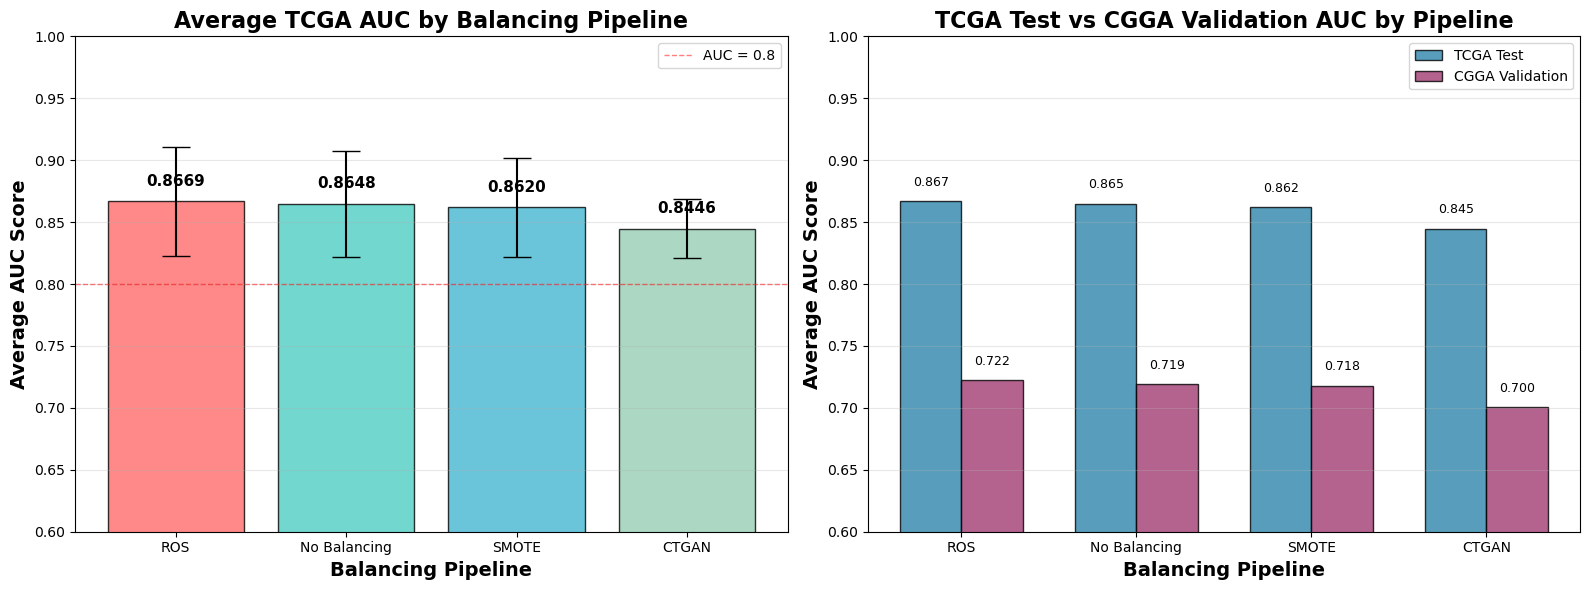



                            DETAILED BAR CHART: ALL METRICS BY PIPELINE                             


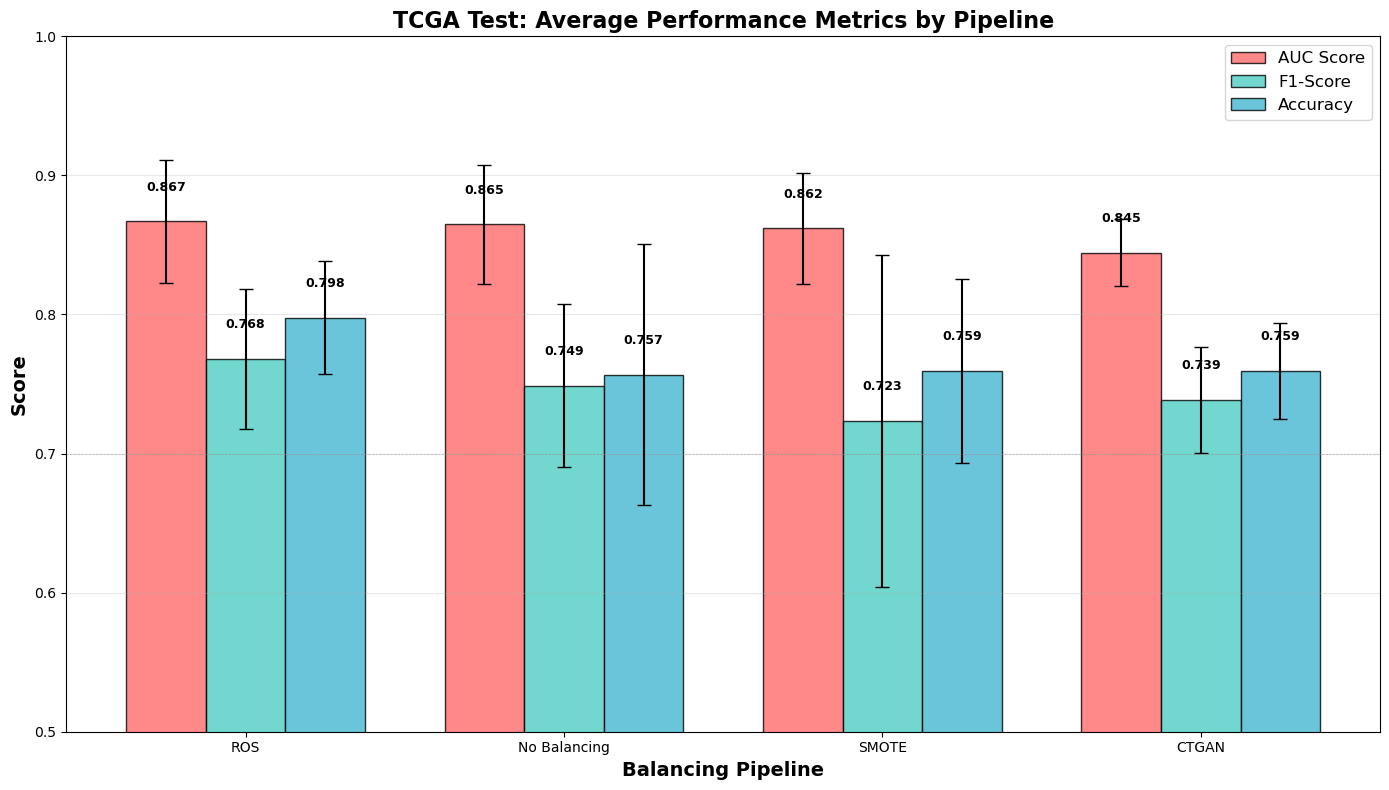



                                      EXPORTING TABLES TO CSV                                       
Exported files:
- pipeline_mean_metrics.csv
- tcga_pipeline_metrics.csv
- cgga_pipeline_metrics.csv
- pipeline_comparison.csv
- tcga_auc_by_pipeline.csv

                                         ANALYSIS COMPLETE                                          

                                         SUMMARY STATISTICS                                         

Best Pipeline by TCGA AUC:
→ ROS: 0.8669

Pipeline Ranking by TCGA AUC:
1. ROS: 0.8669 (±0.0439)
2. No Balancing: 0.8648 (±0.0428)
3. SMOTE: 0.8620 (±0.0399)
4. CTGAN: 0.8446 (±0.0239)

Performance Drop (TCGA → CGGA) by Pipeline:
No Balancing: 0.1458 (TCGA: 0.8648 → CGGA: 0.7190)
ROS: 0.1447 (TCGA: 0.8669 → CGGA: 0.7222)
CTGAN: 0.1442 (TCGA: 0.8446 → CGGA: 0.7004)
SMOTE: 0.1439 (TCGA: 0.8620 → CGGA: 0.7180)


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Read the CSV file
df = pd.read_csv('../V15_results_final.csv')

# Set style for better visualization
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("="*100)
print("MEAN PERFORMANCE METRICS GROUPED BY BALANCING PIPELINE".center(100))
print("="*100)

# 1. Create table of mean performance metrics grouped by pipeline
# Calculate mean metrics for each pipeline across all models and datasets
pipeline_mean = df.groupby('Pipeline').agg({
    'AUC': 'mean',
    'F1': 'mean',
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall_1': 'mean',
    'Recall_0': 'mean'
}).round(4)

# Add count of samples
pipeline_count = df.groupby('Pipeline').size()
pipeline_mean['Count'] = pipeline_count

# Reorder columns
pipeline_mean = pipeline_mean[['Count', 'AUC', 'F1', 'Accuracy', 'Precision', 'Recall_1', 'Recall_0']]

print("\nMean Performance Metrics by Pipeline (across all models and datasets):")
print("\n", pipeline_mean.to_string())
print("-" * 80)

# Display as styled table
styled_pipeline_mean = pipeline_mean.style.background_gradient(cmap='YlOrRd', subset=['AUC', 'F1', 'Accuracy'])\
                                 .format({'AUC': '{:.4f}', 'F1': '{:.4f}', 'Accuracy': '{:.4f}',
                                         'Precision': '{:.4f}', 'Recall_1': '{:.4f}', 'Recall_0': '{:.4f}'})\
                                 .set_properties(**{'text-align': 'center'})\
                                 .set_table_styles([
                                     {'selector': 'th', 
                                      'props': [('font-weight', 'bold'), 
                                               ('text-align', 'center'),
                                               ('background-color', '#f0f0f0')]},
                                     {'selector': 'td', 
                                      'props': [('text-align', 'center')]}
                                 ])
print("\nStyled Table:")
display(styled_pipeline_mean)

# 2. Calculate mean metrics for TCGA Test only
print("\n\n" + "="*100)
print("MEAN PERFORMANCE METRICS FOR TCGA TEST ONLY".center(100))
print("="*100)

tcga_mean = df[df['Dataset'] == 'TCGA Test'].groupby('Pipeline').agg({
    'AUC': 'mean',
    'F1': 'mean',
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall_1': 'mean',
    'Recall_0': 'mean'
}).round(4)

# Add count
tcga_count = df[df['Dataset'] == 'TCGA Test'].groupby('Pipeline').size()
tcga_mean['Count'] = tcga_count

# Reorder columns
tcga_mean = tcga_mean[['Count', 'AUC', 'F1', 'Accuracy', 'Precision', 'Recall_1', 'Recall_0']]

print("\nMean Performance Metrics by Pipeline (TCGA Test only):")
print("\n", tcga_mean.to_string())
print("-" * 80)

# 3. Calculate mean metrics for CGGA only
print("\n\n" + "="*100)
print("MEAN PERFORMANCE METRICS FOR CGGA ONLY".center(100))
print("="*100)

cgga_mean = df[df['Dataset'] == 'CGGA'].groupby('Pipeline').agg({
    'AUC': 'mean',
    'F1': 'mean',
    'Accuracy': 'mean',
    'Precision': 'mean',
    'Recall_1': 'mean',
    'Recall_0': 'mean'
}).round(4)

# Add count
cgga_count = df[df['Dataset'] == 'CGGA'].groupby('Pipeline').size()
cgga_mean['Count'] = cgga_count

# Reorder columns
cgga_mean = cgga_mean[['Count', 'AUC', 'F1', 'Accuracy', 'Precision', 'Recall_1', 'Recall_0']]

print("\nMean Performance Metrics by Pipeline (CGGA only):")
print("\n", cgga_mean.to_string())
print("-" * 80)

# 4. Create comparison table (TCGA vs CGGA)
print("\n\n" + "="*100)
print("TCGA vs CGGA COMPARISON BY PIPELINE".center(100))
print("="*100)

comparison_data = []
for pipeline in df['Pipeline'].unique():
    tcga_auc = df[(df['Pipeline'] == pipeline) & (df['Dataset'] == 'TCGA Test')]['AUC'].mean()
    cgga_auc = df[(df['Pipeline'] == pipeline) & (df['Dataset'] == 'CGGA')]['AUC'].mean()
    tcga_f1 = df[(df['Pipeline'] == pipeline) & (df['Dataset'] == 'TCGA Test')]['F1'].mean()
    cgga_f1 = df[(df['Pipeline'] == pipeline) & (df['Dataset'] == 'CGGA')]['F1'].mean()
    tcga_acc = df[(df['Pipeline'] == pipeline) & (df['Dataset'] == 'TCGA Test')]['Accuracy'].mean()
    cgga_acc = df[(df['Pipeline'] == pipeline) & (df['Dataset'] == 'CGGA')]['Accuracy'].mean()
    
    comparison_data.append({
        'Pipeline': pipeline,
        'TCGA AUC': round(tcga_auc, 4),
        'CGGA AUC': round(cgga_auc, 4),
        'AUC Drop': round(tcga_auc - cgga_auc, 4),
        'TCGA F1': round(tcga_f1, 4),
        'CGGA F1': round(cgga_f1, 4),
        'F1 Drop': round(tcga_f1 - cgga_f1, 4),
        'TCGA Acc': round(tcga_acc, 4),
        'CGGA Acc': round(cgga_acc, 4),
        'Acc Drop': round(tcga_acc - cgga_acc, 4)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('TCGA AUC', ascending=False)

print("\n", comparison_df.to_string(index=False))
print("-" * 80)

# Display styled comparison
styled_comparison = comparison_df.style.background_gradient(cmap='RdYlGn', subset=['AUC Drop', 'F1 Drop', 'Acc Drop'])\
                               .format({'TCGA AUC': '{:.4f}', 'CGGA AUC': '{:.4f}', 'AUC Drop': '{:.4f}',
                                       'TCGA F1': '{:.4f}', 'CGGA F1': '{:.4f}', 'F1 Drop': '{:.4f}',
                                       'TCGA Acc': '{:.4f}', 'CGGA Acc': '{:.4f}', 'Acc Drop': '{:.4f}'})\
                               .set_properties(**{'text-align': 'center'})
print("\nStyled Comparison:")
display(styled_comparison)

# 5. Create Bar Chart: Average TCGA AUC per pipeline
print("\n\n" + "="*100)
print("BAR CHART: AVERAGE TCGA AUC PER PIPELINE".center(100))
print("="*100)

# Calculate average TCGA AUC for each pipeline
tcga_auc_by_pipeline = df[df['Dataset'] == 'TCGA Test'].groupby('Pipeline')['AUC'].agg(['mean', 'std']).round(4)
tcga_auc_by_pipeline = tcga_auc_by_pipeline.sort_values('mean', ascending=False)

print("\nAverage TCGA AUC by Pipeline:")
print(tcga_auc_by_pipeline)

# Create the bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Simple bar chart
ax1 = axes[0]
pipelines = tcga_auc_by_pipeline.index
auc_means = tcga_auc_by_pipeline['mean']
auc_stds = tcga_auc_by_pipeline['std']

# Define colors for each pipeline
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

bars = ax1.bar(pipelines, auc_means, yerr=auc_stds, capsize=10, 
               color=colors, alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels on bars
for i, (bar, mean) in enumerate(zip(bars, auc_means)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize the plot
ax1.set_xlabel('Balancing Pipeline', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average AUC Score', fontsize=14, fontweight='bold')
ax1.set_title('Average TCGA AUC by Balancing Pipeline', fontsize=16, fontweight='bold')
ax1.set_ylim(0.6, 1.0)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='AUC = 0.8')
ax1.legend()

# Plot 2: Grouped bar chart showing TCGA vs CGGA for each pipeline
ax2 = axes[1]

# Prepare data for grouped bar chart
pipeline_order = tcga_auc_by_pipeline.index  # Use same order as first plot
tcga_vals = [comparison_df[comparison_df['Pipeline'] == p]['TCGA AUC'].values[0] for p in pipeline_order]
cgga_vals = [comparison_df[comparison_df['Pipeline'] == p]['CGGA AUC'].values[0] for p in pipeline_order]

x = np.arange(len(pipeline_order))
width = 0.35

bars1 = ax2.bar(x - width/2, tcga_vals, width, label='TCGA Test', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x + width/2, cgga_vals, width, label='CGGA Validation', color='#A23B72', alpha=0.8, edgecolor='black')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Customize
ax2.set_xlabel('Balancing Pipeline', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average AUC Score', fontsize=14, fontweight='bold')
ax2.set_title('TCGA Test vs CGGA Validation AUC by Pipeline', fontsize=16, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pipeline_order)
ax2.set_ylim(0.6, 1.0)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tcga_auc_by_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Create a more detailed bar chart with all metrics
print("\n\n" + "="*100)
print("DETAILED BAR CHART: ALL METRICS BY PIPELINE".center(100))
print("="*100)

fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for all metrics
metrics = ['AUC', 'F1', 'Accuracy']
metric_labels = ['AUC Score', 'F1-Score', 'Accuracy']
pipeline_order = tcga_auc_by_pipeline.index

x = np.arange(len(pipeline_order))
width = 0.25  # Width of each bar
multiplier = 0

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    offset = width * multiplier
    metric_vals = [df[(df['Pipeline'] == p) & (df['Dataset'] == 'TCGA Test')][metric].mean() for p in pipeline_order]
    metric_stds = [df[(df['Pipeline'] == p) & (df['Dataset'] == 'TCGA Test')][metric].std() for p in pipeline_order]
    
    bars = ax.bar(x + offset, metric_vals, width, yerr=metric_stds, capsize=5,
                  label=label, color=color, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add value labels
    for bar, val in zip(bars, metric_vals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
               f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    multiplier += 1

# Customize
ax.set_xlabel('Balancing Pipeline', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('TCGA Test: Average Performance Metrics by Pipeline', fontsize=16, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(pipeline_order)
ax.set_ylim(0.5, 1.0)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.7, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('tcga_metrics_by_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Export tables to CSV
print("\n\n" + "="*100)
print("EXPORTING TABLES TO CSV".center(100))
print("="*100)

pipeline_mean.to_csv('pipeline_mean_metrics.csv')
tcga_mean.to_csv('tcga_pipeline_metrics.csv')
cgga_mean.to_csv('cgga_pipeline_metrics.csv')
comparison_df.to_csv('pipeline_comparison.csv')
tcga_auc_by_pipeline.to_csv('tcga_auc_by_pipeline.csv')

print("Exported files:")
print("- pipeline_mean_metrics.csv")
print("- tcga_pipeline_metrics.csv")
print("- cgga_pipeline_metrics.csv")
print("- pipeline_comparison.csv")
print("- tcga_auc_by_pipeline.csv")

print("\n" + "="*100)
print("ANALYSIS COMPLETE".center(100))
print("="*100)

# 8. Print summary statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS".center(100))
print("="*100)

print("\nBest Pipeline by TCGA AUC:")
best_pipeline = tcga_auc_by_pipeline['mean'].idxmax()
best_auc = tcga_auc_by_pipeline.loc[best_pipeline, 'mean']
print(f"→ {best_pipeline}: {best_auc:.4f}")

print("\nPipeline Ranking by TCGA AUC:")
for i, (pipeline, row) in enumerate(tcga_auc_by_pipeline.iterrows(), 1):
    print(f"{i}. {pipeline}: {row['mean']:.4f} (±{row['std']:.4f})")

print("\nPerformance Drop (TCGA → CGGA) by Pipeline:")
comparison_df_sorted = comparison_df.sort_values('AUC Drop', ascending=False)
for _, row in comparison_df_sorted.iterrows():
    print(f"{row['Pipeline']}: {row['AUC Drop']:.4f} (TCGA: {row['TCGA AUC']:.4f} → CGGA: {row['CGGA AUC']:.4f})")